# EV Charging Curve Classification
## Modelling with LSTM and TCN Architectures
#### by Sebastian Einar Salas Røkholt
----

### Index
**1. Setup** </br>
**2. Data Preparation**</br>
**3. Modelling**</br>
*3.1 Model Architectures*</br>
*3.2 Model Training with Ray Tune & BOHB*</br>
*3.3 
**4. Model Evaluation and Selection**</br>
**+++**</br>


### Introduction
This notebook develops and evaluates deep learning models for multivariate, multi-horizon time series forecasting of EV charging sessions. The goal is to predict power and state-of-charge (SoC) trajectories from partial charging data, enabling both accurate forecasting and anomaly detection.

We compare two sequence modelling approaches:

**Long Short-Term Memory (LSTM) networks**, which learn temporal dependencies through gated recurrent units.

**Temporal Convolutional Networks (TCN)**, which exploit causal convolutions and dilations to capture long-range dependencies efficiently.

We train both models with PyTorch, and tune them with Ray Tune by leveraging **Bayesian optimization with HyperBand (BOHB)**.

 ## 1 - Setup

In [36]:
import os, gc, math, random, tempfile
from dataclasses import dataclass
from collections import OrderedDict
from typing import Tuple, List, Callable, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.utils.rnn as rnn_utils
from torch.nn.utils import weight_norm
from torch.utils.data import DataLoader, Dataset, Sampler
from torch.amp import autocast, GradScaler
import ray
from ray import tune
from ray.air import session
from ray.train import Checkpoint  # Should be updated, this is degraded
from ray.tune import ExperimentAnalysis
from ray.tune.tuner import Tuner, TuneConfig, RunConfig
from ray.tune.schedulers import HyperBandForBOHB
from ray.tune.search.bohb import TuneBOHB
import ConfigSpace as CS
import ConfigSpace.hyperparameters as CSH
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error

# Notebook global constants
RANDOM_SEED = 42
TRAIN_LSTM = False
TRAIN_TCN  = True
BATCH_SIZE  = 256
NUM_WORKERS = 8
HORIZON     = 5

# Global paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
MODEL_FOLDER_PATH = os.path.join(PROJECT_ROOT, "Models")
MODEL_NAME_LSTM = "LSTM_multihorizon_raytuned_model_6.pth"
MODEL_NAME_TCN  = "TCN_multihorizon_raytuned_model_1.pth"
MODEL_PATH_LSTM = os.path.join(MODEL_FOLDER_PATH, MODEL_NAME_LSTM)
MODEL_PATH_TCN  = os.path.join(MODEL_FOLDER_PATH, MODEL_NAME_TCN)
RAY_TUNE_FOLDER_NAME_LSTM = "bohb_lstm_tuning_run_6"
RAY_TUNE_FOLDER_NAME_TCN  = "bohb_tcn_tuning_run_1"
RAY_TUNE_RUN_FOLDER_PATH_LSTM = os.path.join(MODEL_FOLDER_PATH, RAY_TUNE_FOLDER_NAME_LSTM)
RAY_TUNE_RUN_FOLDER_PATH_TCN  = os.path.join(MODEL_FOLDER_PATH, RAY_TUNE_FOLDER_NAME_TCN)

# Package and notebook settings
torch.manual_seed(RANDOM_SEED)
torch.backends.cudnn.benchmark = True
ray.shutdown()
ray.init(ignore_reinit_error=True)
sns.set_theme(style="whitegrid")
pd.options.mode.copy_on_write = True
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:.2f}".format

print("[env] CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("[env] Device:", torch.cuda.get_device_name(torch.cuda.current_device()))
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

2025-08-19 12:49:29,611	INFO worker.py:1927 -- Started a local Ray instance.


[env] CUDA available: True
[env] Device: NVIDIA GeForce RTX 4070 Laptop GPU


#### 1.1 Feature selection 
In order to predict `soc` and `power` output for the next `HORIZON` (e.g. 5) timesteps, the model will use the `soc` and `power` values from the `sequence_length` (e.g. 15) previous timesteps/minutes. In addition, there are two static (non time-dependent, per-session) features that we believe the model will use to enhance its predictive abilities. The first static feature is `temp`, the approximate ambient temperature (rounded to the nearest integer) at the start of the charging session. Charging speed is directly influenced by the vehicle's battery temperature, because at lower temperatures, the chemical processes in the battery slow down. Lithium-ion batteries may also experience lithium plating if charged to quickly at low temperatures, so both vehicle and charging station manufacturers place automatic restrictions that limit the energy transfer. As we do not have access to battery temperature data from each vehciel, we have collected ambient air temperature  data instead, which we believe might be a good explanatory environmental variable as the ambient temperature is one of several causal factors that influence the battery temperature. Other factors are vehicle usage, charging duration, and the vehicle's thermal management system.
The second static feature we will be using is `nominal_power`, which is the charging station's maximum power output as stated by the manufacturer. As different types of charging stations are likely to have significantly different power output distributions, we believe that this static feature will help the model determine what the likely value range will be, especially at the start of the charging session. 

The dataset contains a few other features, but these will not be used for modelling. This is mainly, because these features are either derived from other features or were used in the feature engineering step to calculate other derived features. For example, `energy` (in kWh) is simply the `power` (in kW) aggregated to the hour, while `lat` (latitude) and `lon` (longitude) were used to retrieve temperature data. The geographical position of the charging station is unlikely to be a useful predictor for our target variables. 

In [2]:
# Load the cleaned dataframe
df = pd.read_parquet("../Data/etron55-charging-sessions.parquet")
print(f"Features: {df.columns}")

base_cols = ["charging_id", "minutes_elapsed", "power", "soc", "temp", "nominal_power"]
df = df[base_cols].copy()
df.head()


Features: Index(['charging_id', 'timestamp', 'minutes_elapsed', 'soc', 'power', 'energy',
       'charger_category', 'nominal_power', 'temp', 'lat', 'lon'],
      dtype='object')


,charging_id,minutes_elapsed,power,soc,temp,nominal_power
0,0,0,89.44,40.00,4,150.00
1,0,1,92.75,41.00,4,150.00
2,0,2,94.81,43.00,4,150.00
3,0,3,95.68,45.00,4,150.00
4,0,4,96.88,47.00,4,150.00


In [3]:
df.tail()

,charging_id,minutes_elapsed,power,soc,temp,nominal_power
1590118,12657311,11,126.05,57.00,7,360.00
1590119,12657311,12,126.95,60.00,7,360.00
1590120,12657311,13,127.97,62.00,7,360.00
1590121,12657311,14,128.01,65.00,7,360.00
1590122,12657311,15,129.47,67.00,7,360.00


## 2 - Data preparation

More feature engineering - move this to notebook 01!

In [4]:
# Progress feature (log-scaled minutes)
df["progress"] = np.log1p(df["minutes_elapsed"]) / np.log1p(120.0)

# Relative power (clipped, normalized)
denom = np.clip(df["nominal_power"].astype(float).values, 1e-6, None)
rel = (df["power"].astype(float).values / denom)
rel = np.clip(rel, 0.0, 1.2)
df["rel_power"] = rel / 1.2

# Deltas + EMA3 per session (original units)
df["d_power"] = df.groupby("charging_id", observed=False)["power"].diff().fillna(0.0)
df["d_soc"]   = df.groupby("charging_id", observed=False)["soc"].diff().fillna(0.0)
df["d_power_ema3"] = df.groupby("charging_id", observed=False)["d_power"] \
                       .transform(lambda s: s.ewm(span=3, adjust=False).mean()).fillna(0.0)
df["d_soc_ema3"]   = df.groupby("charging_id", observed=False)["d_soc"] \
                       .transform(lambda s: s.ewm(span=3, adjust=False).mean()).fillna(0.0)

# Charger category OHE from nominal_power
bins, labels = [0, 75, 200, np.inf], ["low", "mid", "high"]
df["charger_cat_bin"] = pd.cut(df["nominal_power"].astype(float), bins=bins,
                               labels=labels, include_lowest=True, right=True)
charger_ohe = pd.get_dummies(df["charger_cat_bin"], prefix="charger_cat", dtype=np.float32)
if charger_ohe.shape[1] == 0:
    charger_ohe = pd.DataFrame(0.0, index=df.index,
                               columns=["charger_cat_low","charger_cat_mid","charger_cat_high"])
df = pd.concat([df.drop(columns=["charger_cat_bin"]), charger_ohe], axis=1)
charger_ohe_cols = charger_ohe.columns.tolist()

# -- Feature lists --
fixed_features = ["temp", "nominal_power"]
target_features = ["power", "soc"]
dynamic_features = ["progress", "rel_power", "d_power", "d_soc", "d_power_ema3", "d_soc_ema3"]
input_features = fixed_features + charger_ohe_cols + target_features + dynamic_features

# Index helpers for dynamic targets (used throughout)
IDX_TEMP = input_features.index("temp")
IDX_NOM = input_features.index("nominal_power")
IDX_POWER = input_features.index("power")
IDX_SOC = input_features.index("soc")

df.head()

,charging_id,minutes_elapsed,power,soc,temp,nominal_power,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,charger_cat_low,charger_cat_mid,charger_cat_high
0,0,0,89.44,40.00,4,150.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,1.00,0.00
1,0,1,92.75,41.00,4,150.00,0.14,0.52,3.31,1.00,1.66,0.50,0.00,1.00,0.00
2,0,2,94.81,43.00,4,150.00,0.23,0.53,2.06,2.00,1.86,1.25,0.00,1.00,0.00
3,0,3,95.68,45.00,4,150.00,0.29,0.53,0.87,2.00,1.36,1.62,0.00,1.00,0.00
4,0,4,96.88,47.00,4,150.00,0.34,0.54,1.20,2.00,1.28,1.81,0.00,1.00,0.00


#### 2.1 - Splitting the data 
The code below splits the dataset into training, validation and test sets. </br>
`GroupShuffleSplit` ensures that a charging session isn't split across multiple sets.

In [5]:
def split_data(df: pd.DataFrame, test_size: float=0.2, validation_size: float=0.1):
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_SEED)
    train_val_idx, test_idx = next(gss_test.split(df, groups=df["charging_id"]))
    train_val_df = df.iloc[train_val_idx]

    adj_val_size = validation_size / (1 - test_size)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=adj_val_size, random_state=RANDOM_SEED)
    train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df["charging_id"]))

    train_df = train_val_df.iloc[train_idx]
    val_df   = train_val_df.iloc[val_idx]
    test_df  = df.iloc[test_idx]
    return train_df, val_df, test_df

train_df, val_df, test_df = split_data(df)
print(f"Training set size: {len(train_df)} ({round(100*(len(train_df)/len(df)), 1)}%)\n"
      f"Validation set size: {len(val_df)} ({round(100*(len(val_df)/len(df)), 1)}%)\n"
      f"Test set size: {len(test_df)} ({round(100*(len(test_df)/len(df)), 1)}%)\n"
      f"Total size: {len(df)}")


Training set size: 1113061 (70.0%)
Validation set size: 159426 (10.0%)
Test set size: 317636 (20.0%)
Total size: 1590123


In [10]:
train_df.head()

,charging_id,minutes_elapsed,power,soc,temp,nominal_power,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,charger_cat_low,charger_cat_mid,charger_cat_high
0,0,0,89.44,40.00,4,150.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,1.00,0.00
1,0,1,92.75,41.00,4,150.00,0.14,0.52,3.31,1.00,1.66,0.50,0.00,1.00,0.00
2,0,2,94.81,43.00,4,150.00,0.23,0.53,2.06,2.00,1.86,1.25,0.00,1.00,0.00
3,0,3,95.68,45.00,4,150.00,0.29,0.53,0.87,2.00,1.36,1.62,0.00,1.00,0.00
4,0,4,96.88,47.00,4,150.00,0.34,0.54,1.20,2.00,1.28,1.81,0.00,1.00,0.00


#### 2.2 - Data normalisation


In [ ]:
# MinMax scaling
fixed_features_scaler = MinMaxScaler((0, 1))
power_scaler = MinMaxScaler((0, 1))
soc_scaler = MinMaxScaler((0, 1))
delta_features = ["d_power", "d_soc", "d_power_ema3", "d_soc_ema3"]
delta_scaler = MinMaxScaler((0, 1))

fixed_features_scaler.fit(train_df[fixed_features])
power_scaler.fit(train_df[["power"]])
soc_scaler.fit(train_df[["soc"]])
delta_scaler.fit(train_df[delta_features])

def apply_scaling(df_: pd.DataFrame):
    df_[fixed_features] = fixed_features_scaler.transform(df_[fixed_features])
    df_["power"] = power_scaler.transform(df_[["power"]])
    df_["soc"]   = soc_scaler.transform(df_[["soc"]])
    df_[delta_features] = delta_scaler.transform(df_[delta_features])
    return df_

train_df = apply_scaling(train_df)
val_df   = apply_scaling(val_df)
test_df  = apply_scaling(test_df)

display(train_df.head())

# To be used later for inverse transforms
POWER_MIN = float(power_scaler.data_min_[0]); POWER_MAX = float(power_scaler.data_max_[0])
SOC_MIN   = float(soc_scaler.data_min_[0]);   SOC_MAX   = float(soc_scaler.data_max_[0])

,charging_id,minutes_elapsed,power,soc,temp,nominal_power,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,charger_cat_low,charger_cat_mid,charger_cat_high
0,0,0,0.33,0.39,0.56,0.22,0.00,0.50,0.51,0.10,0.51,0.03,0.00,1.00,0.00
1,0,1,0.35,0.40,0.56,0.22,0.14,0.52,0.52,0.20,0.52,0.11,0.00,1.00,0.00
2,0,2,0.35,0.42,0.56,0.22,0.23,0.53,0.51,0.30,0.52,0.24,0.00,1.00,0.00
3,0,3,0.36,0.44,0.56,0.22,0.29,0.53,0.51,0.30,0.52,0.30,0.00,1.00,0.00
4,0,4,0.36,0.46,0.56,0.22,0.34,0.54,0.51,0.30,0.52,0.33,0.00,1.00,0.00


 ### 2.3 - Building the datasets and data loaders

 Write a description here

In [16]:
# -- Packed per-session dataset with horizon residual targets --
class ChargingSessionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, input_features: List[str], target_features: List[str], horizon: int=5):
        super().__init__()
        self.input_features = input_features
        self.target_features = target_features
        self.horizon = horizon
        self.num_targets = len(target_features)
        self.sessions = []

        for _, session_df in df.groupby("charging_id", observed=False):
            session_df = session_df.sort_values("minutes_elapsed")
            X = session_df[self.input_features].values
            Y_raw = session_df[self.target_features].values
            L = len(X)
            if L < (self.horizon + 1):
                continue

            Y_h = np.zeros((L, self.horizon, self.num_targets), dtype=np.float32)
            for i in range(L):
                for h in range(1, self.horizon + 1):
                    j = i + h
                    if j < L:
                        Y_h[i, h-1] = (Y_raw[j] - Y_raw[i])

            self.sessions.append((X.astype(np.float32), Y_h))

    def __len__(self): return len(self.sessions)

    def __getitem__(self, idx):
        X, Y = self.sessions[idx]
        return X, Y, X.shape[0]

# -- Bucketed batch sampler by session length --
class BucketBatchSampler(Sampler):
    def __init__(self, dataset: ChargingSessionDataset, batch_size: int, shuffle: bool=True):
        self.dataset = dataset; self.batch_size = batch_size; self.shuffle = shuffle
        lengths = [(i, dataset.sessions[i][0].shape[0]) for i in range(len(dataset))]
        self.sorted_indices = [i for i,_ in sorted(lengths, key=lambda x: x[1])]
        self.batches = [self.sorted_indices[i:i+batch_size] for i in range(0, len(self.sorted_indices), batch_size)]
        if self.shuffle: random.shuffle(self.batches)
    def __iter__(self):
        if self.shuffle: random.shuffle(self.batches)
        for b in self.batches: yield b
    def __len__(self): return math.ceil(len(self.sorted_indices) / self.batch_size)

# -- Collate with padding to (B, T_max, ...) --
def session_collate_fn(batch: List[Tuple[np.ndarray, np.ndarray, int]]):
    all_x, all_y, lengths = zip(*batch)
    max_len     = max(lengths)
    horizon     = all_y[0].shape[1]
    num_targets = all_y[0].shape[2]
    input_size  = all_x[0].shape[1]

    Xp = np.zeros((len(batch), max_len, input_size), dtype=np.float32)
    Yp = np.zeros((len(batch), max_len, horizon, num_targets), dtype=np.float32)
    for i, (x, y, L) in enumerate(batch):
        Xp[i, :L] = x; Yp[i, :L] = y

    return torch.from_numpy(Xp).float(), torch.from_numpy(Yp).float(), torch.tensor(lengths, dtype=torch.long)


# Build the datasets
train_dataset = ChargingSessionDataset(train_df, input_features, target_features, horizon=HORIZON)
val_dataset   = ChargingSessionDataset(val_df,   input_features, target_features, horizon=HORIZON)
test_dataset  = ChargingSessionDataset(test_df,  input_features, target_features, horizon=HORIZON)

print(f"Input features: {input_features}")
print(f"First session in training data: ")
train_dataset.sessions[0][0]

Input features: ['temp', 'nominal_power', 'charger_cat_low', 'charger_cat_mid', 'charger_cat_high', 'power', 'soc', 'progress', 'rel_power', 'd_power', 'd_soc', 'd_power_ema3', 'd_soc_ema3']
First session in training data: 


array([[0.5645161 , 0.22222222, 0.        , 1.        , 0.        ,
        0.33399305, 0.3939394 , 0.        , 0.49688888, 0.5058503 ,
        0.1       , 0.5116554 , 0.03449224],
       [0.5645161 , 0.22222222, 0.        , 1.        , 0.        ,
        0.34635347, 0.4040404 , 0.14453241, 0.5152778 , 0.5168528 ,
        0.2       , 0.5228309 , 0.11494794],
       [0.5645161 , 0.22222222, 0.        , 1.        , 0.        ,
        0.35404608, 0.42424244, 0.22907846, 0.5267222 , 0.51269776,
        0.3       , 0.5241983 , 0.23563151],
       [0.5645161 , 0.22222222, 0.        , 1.        , 0.        ,
        0.3572949 , 0.44444445, 0.28906482, 0.53155553, 0.5087422 ,
        0.3       , 0.5208642 , 0.2959733 ],
       [0.5645161 , 0.22222222, 0.        , 1.        , 0.        ,
        0.36177602, 0.46464646, 0.33559388, 0.5382222 , 0.5098391 ,
        0.3       , 0.52031136, 0.3261442 ],
       [0.5645161 , 0.22222222, 0.        , 1.        , 0.        ,
        0.36453938, 0.47474

 ## 3 - Model Architectures

LSTM & TCN

### 3.1 Defining the LSTM Architecture

In [ ]:
# -- LSTM multi-horizon residual model --
class MultiHorizonLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_dim: int, horizon: int, num_targets: int,
                 num_layers: int, dropout: float=0.0):
        super().__init__()
        self.horizon = horizon; self.num_targets = num_targets
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0,
        )
        self.linear = nn.Linear(hidden_dim, horizon * num_targets)

    def forward(self, x: torch.Tensor, seq_lengths: torch.Tensor):
        packed_x = rnn_utils.pack_padded_sequence(x, seq_lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed_x)
        out, out_lengths = rnn_utils.pad_packed_sequence(packed_out, batch_first=True)
        out = self.linear(out).view(out.shape[0], out.shape[1], self.horizon, self.num_targets)
        return out, out_lengths

### 3.2 Defining the TCN Architecture

In [ ]:
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = weight_norm(nn.Conv1d(in_ch, out_ch, kernel_size, padding=0, dilation=dilation))
    def forward(self, x):  # (B,C,T)
        x = nn.functional.pad(x, (self.pad, 0))
        return self.conv(x)

class TCNBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation, dropout):
        super().__init__()
        c = channels
        self.conv1 = CausalConv1d(c, c, kernel_size, dilation=dilation)
        self.relu1 = nn.ReLU(); self.do1 = nn.Dropout(dropout)
        self.conv2 = CausalConv1d(c, c, kernel_size, dilation=dilation)
        self.relu2 = nn.ReLU(); self.do2 = nn.Dropout(dropout)
    def forward(self, x):
        out = self.do1(self.relu1(self.conv1(x)))
        out = self.do2(self.relu2(self.conv2(out)))
        return out + x

class TemporalConvNet(nn.Module):
    def __init__(self, channels, num_layers, kernel_size, dropout):
        super().__init__()
        self.net = nn.Sequential(*[
            TCNBlock(channels, kernel_size, dilation=(2 ** i), dropout=dropout) for i in range(num_layers)
        ])
    def forward(self, x): return self.net(x)

class MultiHorizonTCN(nn.Module):
    def __init__(self, input_size: int, hidden_dim: int, num_layers: int,
                 kernel_size: int, horizon: int, num_targets: int, dropout: float=0.0):
        super().__init__()
        self.horizon = horizon; self.num_targets = num_targets
        self.input_proj = nn.Conv1d(input_size, hidden_dim, kernel_size=1)
        self.tcn = TemporalConvNet(hidden_dim, num_layers, kernel_size, dropout)
        self.head = nn.Conv1d(hidden_dim, horizon * num_targets, kernel_size=1)

    def forward(self, x: torch.Tensor, seq_lengths: torch.Tensor):
        B, T, F = x.shape
        h = self.input_proj(x.transpose(1, 2))
        h = self.tcn(h)
        y = self.head(h).transpose(1, 2).view(B, T, self.horizon, self.num_targets)
        return y, seq_lengths


### 3.3 Additional Learnable Weights

#### 3.3.1 Target Uncertainty Weights

In [ ]:
# Learnable target uncertainty weighting (power vs soc)
class UncertaintyWeights(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_var_power = nn.Parameter(torch.tensor(0.0))
        self.log_var_soc   = nn.Parameter(torch.tensor(0.0))
    def forward(self, loss_power, loss_soc):
        prec_p = torch.exp(-self.log_var_power)
        prec_s = torch.exp(-self.log_var_soc)
        return 0.5 * (prec_p * loss_power + prec_s * loss_soc) + 0.5 * (self.log_var_power + self.log_var_soc)

#### 3.3.2 Horizon Weights

In [ ]:
# Horizon weights exp(-alpha * (h-1)) as (1,1,H,1)
def _horizon_weights(H: int, alpha: float, device: torch.device):
    w = torch.exp(-alpha * torch.arange(1, H+1, device=device, dtype=torch.float32))
    return w.view(1, 1, H, 1)

### 3.4 Model Builders

In [ ]:
def build_model_lstm(cfg):
    return MultiHorizonLSTM(
        input_size=len(input_features),
        hidden_dim=int(cfg["hidden_dim"]),
        horizon=HORIZON,
        num_targets=len(target_features),
        num_layers=int(cfg["num_layers"]),
        dropout=float(cfg.get("dropout", 0.0)),
    ).to(DEVICE)

def build_model_tcn(cfg):
    return MultiHorizonTCN(
        input_size=len(input_features),
        hidden_dim=int(cfg["hidden_dim"]),
        num_layers=int(cfg["num_layers"]),
        kernel_size=int(cfg["kernel_size"]),
        horizon=HORIZON,
        num_targets=len(target_features),
        dropout=float(cfg.get("dropout", 0.0)),
    ).to(DEVICE)


## 4 - Model Training
In this section we define a new training function compatible with Ray Tune, 
and then launch a BOHB hyperparameter search. 


### 4.1 Training Utilities

In [ ]:
# -- Optimizer with decoupled weight decay, no decay on biases/1D params --
def _build_adamw(named_params, lr, weight_decay):
    decay, no_decay = [], []
    for _, p in named_params:
        if not p.requires_grad: continue
        (decay if p.ndim > 1 else no_decay).append(p)
    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": weight_decay}, {"params": no_decay, "weight_decay": 0.0}],
        lr=lr
    )

# -- Ray ObjectRef duck-typing for dataset resolution (robust to versions) --
try:
    from ray import ObjectRef  # type: ignore
except Exception:
    ObjectRef = tuple()

def _resolve_dataset_ref(maybe_ref):
    if isinstance(maybe_ref, ObjectRef): return ray.get(maybe_ref)
    if hasattr(maybe_ref, "__len__") and hasattr(maybe_ref, "__getitem__"): return maybe_ref
    if isinstance(maybe_ref, type):
        raise ValueError("Got a class instead of a dataset instance/ObjectRef. Use ray.put(dataset).")
    raise ValueError(f"Invalid dataset ref type: {type(maybe_ref)}")

# -- Inverse MinMax for a specific channel of shape (B,T,H,C) to (B,T,H,1) --
def inv_minmax_channel_torch(t_scaled: torch.Tensor, min_val: torch.Tensor, max_val: torch.Tensor, ch: int):
    return t_scaled[..., ch:ch+1] * (max_val - min_val) + min_val

# -- Valid mask 1 <= i < len-horizon → (B,T,H,1) --
def _vectorized_mask(lengths: torch.Tensor, T_max: int, horizon: int, device):
    B = lengths.shape[0]
    t = torch.arange(T_max, device=device).unsqueeze(0).expand(B, -1)
    end = lengths.to(device).unsqueeze(1) - horizon
    mask_2d = (t >= 1) & (t < end)
    return mask_2d.unsqueeze(-1).expand(-1, -1, horizon).unsqueeze(-1)

# -- Residual → absolute (scaled space) using current inputs X --
def reconstruct_abs_from_residuals_batch(pred_resid: torch.Tensor, X_batch: torch.Tensor, idx_power: int, idx_soc: int):
    base = torch.stack([X_batch[..., idx_power], X_batch[..., idx_soc]], dim=-1).unsqueeze(2)
    return pred_resid + base

# -- Loader builders per trial (supports batch size tuning) --
def _build_loaders_for_trial_from_datasets(train_dataset_local, val_dataset_local, batch_size: int):
    train_sampler_local = BucketBatchSampler(train_dataset_local, batch_size=batch_size, shuffle=True)
    val_sampler_local   = BucketBatchSampler(val_dataset_local,   batch_size=batch_size, shuffle=False)
    train_loader_local = DataLoader(
        train_dataset_local, batch_sampler=train_sampler_local, collate_fn=session_collate_fn,
        num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2, persistent_workers=(NUM_WORKERS > 0)
    )
    val_loader_local = DataLoader(
        val_dataset_local, batch_sampler=val_sampler_local, collate_fn=session_collate_fn,
        num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2, persistent_workers=(NUM_WORKERS > 0)
    )
    return train_loader_local, val_loader_local

### 4.2 Defining the Ray Trainables

In [ ]:
# Generic trainable reusing loss/masking/metric logic
def tune_train_generic(
    config,
    checkpoint_dir=None,
    train_dataset_ref=None,
    val_dataset_ref=None,
    model_builder: Optional[Callable[[dict], nn.Module]] = None
):
    device = DEVICE
    pmin = torch.tensor(POWER_MIN, device=device); pmax = torch.tensor(POWER_MAX, device=device)
    smin = torch.tensor(SOC_MIN,   device=device); smax = torch.tensor(SOC_MAX,   device=device)

    hidden_dim    = int(config["hidden_dim"])
    num_layers    = int(config["num_layers"])
    dropout       = float(config.get("dropout", 0.0))
    lr            = float(config["lr"])
    weight_decay  = float(config.get("weight_decay", 0.0))
    grad_clip     = float(config.get("grad_clip_norm", 0.0))
    num_epochs    = int(config["num_epochs"])
    batch_size    = int(config.get("batch_size", 64))
    power_weight  = float(config.get("power_weight", 0.7))
    alpha_h       = float(config.get("alpha_h", 0.35))

    train_dataset_local = _resolve_dataset_ref(train_dataset_ref)
    val_dataset_local   = _resolve_dataset_ref(val_dataset_ref)

    assert model_builder is not None, "model_builder must be provided."
    model = model_builder(config)
    uw    = UncertaintyWeights().to(device)

    named = list(model.named_parameters()) + [(f"uw.{n}", p) for n, p in uw.named_parameters()]
    optimizer = _build_adamw(named, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4, verbose=False)
    scaler    = GradScaler(device="cuda", enabled=torch.cuda.is_available())

    train_loader_local, val_loader_local = _build_loaders_for_trial_from_datasets(
        train_dataset_local, val_dataset_local, batch_size
    )

    for epoch in range(num_epochs):
        # ---- Train ----
        model.train()
        train_loss_sum, train_count = 0.0, 0
        for X_batch, Y_batch, lengths in train_loader_local:
            X_batch = X_batch.to(device, non_blocking=True)
            Y_batch = Y_batch.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type="cuda" if torch.cuda.is_available() else "cpu"):
                pred_resid, _ = model(X_batch, lengths)
                B, T, H, C = pred_resid.shape
                mask_4d = _vectorized_mask(lengths, T_max=T, horizon=H, device=device)
                w_h = _horizon_weights(H, alpha_h, device)

                P_abs_s = reconstruct_abs_from_residuals_batch(pred_resid, X_batch, IDX_POWER, IDX_SOC)
                Y_abs_s = Y_batch + X_batch[..., [IDX_POWER, IDX_SOC]].unsqueeze(2)

                P_kw   = inv_minmax_channel_torch(P_abs_s, min_val=pmin, max_val=pmax, ch=0)
                Y_kw   = inv_minmax_channel_torch(Y_abs_s, min_val=pmin, max_val=pmax, ch=0)
                P_socU = inv_minmax_channel_torch(P_abs_s, min_val=smin, max_val=smax, ch=1)
                Y_socU = inv_minmax_channel_torch(Y_abs_s, min_val=smin, max_val=smax, ch=1)

                huber_kw  = torch.nn.functional.smooth_l1_loss(P_kw,   Y_kw,   reduction="none")
                huber_soc = torch.nn.functional.smooth_l1_loss(P_socU, Y_socU, reduction="none")

                loss_kw  = (huber_kw  * w_h)[mask_4d].mean()
                loss_soc = (huber_soc * w_h)[mask_4d].mean()
                loss = uw(loss_kw, loss_soc)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if grad_clip and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer); scaler.update()

            n_valid = mask_4d.sum().item()
            train_loss_sum += loss.detach().item() * max(n_valid, 1)
            train_count    += max(n_valid, 1)

        avg_train_loss = (train_loss_sum / train_count) if train_count > 0 else float("nan")

        # ---- Validation ----
        model.eval()
        val_loss_sum, val_count = 0.0, 0
        val_rmse_power, val_rmse_soc, val_metric = float("nan"), float("nan"), float("nan")
        with torch.no_grad():
            se_p, se_s, n_p, n_s = 0.0, 0.0, 0, 0
            for X_batch, Y_batch, lengths in val_loader_local:
                X_batch = X_batch.to(device, non_blocking=True)
                Y_batch = Y_batch.to(device, non_blocking=True)

                pred_resid, _ = model(X_batch, lengths)
                B, T, H, C = pred_resid.shape
                mask_4d = _vectorized_mask(lengths, T_max=T, horizon=H, device=device)
                w_h = _horizon_weights(H, alpha_h, device)

                P_abs_s = reconstruct_abs_from_residuals_batch(pred_resid, X_batch, IDX_POWER, IDX_SOC)
                Y_abs_s = Y_batch + X_batch[..., [IDX_POWER, IDX_SOC]].unsqueeze(2)

                P_kw   = inv_minmax_channel_torch(P_abs_s, min_val=pmin, max_val=pmax, ch=0)
                Y_kw   = inv_minmax_channel_torch(Y_abs_s, min_val=pmin, max_val=pmax, ch=0)
                P_socU = inv_minmax_channel_torch(P_abs_s, min_val=smin, max_val=smax, ch=1)
                Y_socU = inv_minmax_channel_torch(Y_abs_s, min_val=smin, max_val=smax, ch=1)

                vloss_kw  = torch.nn.functional.smooth_l1_loss(((P_kw   - Y_kw)   * w_h)[mask_4d],
                                                               torch.zeros(1, device=device), reduction="mean")
                vloss_soc = torch.nn.functional.smooth_l1_loss(((P_socU - Y_socU) * w_h)[mask_4d],
                                                               torch.zeros(1, device=device), reduction="mean")
                vloss = uw(vloss_kw, vloss_soc)

                n_valid = mask_4d.sum().item()
                val_loss_sum += vloss.item() * max(n_valid, 1)
                val_count    += max(n_valid, 1)

                mask3 = mask_4d.expand_as(P_kw)
                diff_p = (P_kw - Y_kw)[mask3]; diff_s = (P_socU - Y_socU)[mask3]
                if diff_p.numel() > 0: se_p += float((diff_p ** 2).sum().item()); n_p += int(diff_p.numel())
                if diff_s.numel() > 0: se_s += float((diff_s ** 2).sum().item()); n_s += int(diff_s.numel())

            if n_p > 0: val_rmse_power = math.sqrt(se_p / n_p)
            if n_s > 0: val_rmse_soc   = math.sqrt(se_s / n_s)
            val_metric = (power_weight * val_rmse_power + (1.0 - power_weight) * val_rmse_soc
                          if not (math.isnan(val_rmse_power) or math.isnan(val_rmse_soc))
                          else float(val_loss_sum / max(val_count, 1)))

        avg_val_loss = (val_loss_sum / val_count) if val_count > 0 else float("nan")
        scheduler.step(val_metric if not math.isnan(val_metric) else avg_val_loss)

        # -- Periodic checkpoint --
        ckpt = None
        if (epoch + 1) % 3 == 0 or (epoch + 1) == num_epochs:
            tmpdir = tempfile.mkdtemp()
            torch.save({"model": model.state_dict(), "uw": uw.state_dict()}, os.path.join(tmpdir, "checkpoint.pt"))
            ckpt = Checkpoint.from_directory(tmpdir)

        session.report({
            "epoch": int(epoch + 1),
            "train_loss": float(avg_train_loss),
            "val_loss": float(avg_val_loss),
            "val_metric": float(val_metric),
            "val_rmse_power": float(val_rmse_power),
            "val_rmse_soc": float(val_rmse_soc),
            "lr": float(optimizer.param_groups[0]["lr"]),
            "alpha_h": float(alpha_h),
            "prec_power": float(torch.exp(-uw.log_var_power).item()),
            "prec_soc":   float(torch.exp(-uw.log_var_soc).item()),
        }, checkpoint=ckpt)

# -- Thin wrappers to keep LSTM/TCN trainables distinct in Ray Tune UI --
def tune_train_lstm(config, checkpoint_dir=None, train_dataset_ref=None, val_dataset_ref=None):
    return tune_train_generic(config, checkpoint_dir, train_dataset_ref, val_dataset_ref, model_builder=build_model_lstm)

def tune_train_tcn(config, checkpoint_dir=None, train_dataset_ref=None, val_dataset_ref=None):
    return tune_train_generic(config, checkpoint_dir, train_dataset_ref, val_dataset_ref, model_builder=build_model_tcn)


### 4.3 Hyperparameter Search Spaces and Result Plotting Utilities

In [ ]:
# -- BOHB spaces (separate for LSTM/TCN) --
def make_bohb_cs_for_lstm(seed=RANDOM_SEED):
    cs = CS.ConfigurationSpace(seed=seed)
    cs.add([
        CSH.CategoricalHyperparameter("hidden_dim", [64, 128, 192, 256, 384, 512]),
        CSH.CategoricalHyperparameter("num_layers", [1, 2, 3, 4, 5]),
        CSH.UniformFloatHyperparameter("dropout", lower=0.0, upper=0.3),
        CSH.UniformFloatHyperparameter("lr", lower=3e-4, upper=3e-2, log=True),
        CSH.UniformFloatHyperparameter("weight_decay", lower=1e-6, upper=3e-3, log=True),
        CSH.CategoricalHyperparameter("batch_size", [32, 64, 96]),
        CSH.CategoricalHyperparameter("grad_clip_norm", [0.0, 1.0, 3.0, 5.0]),
        CSH.UniformFloatHyperparameter("power_weight", lower=0.65, upper=0.9),
        CSH.UniformFloatHyperparameter("alpha_h", lower=0.20, upper=0.55),
        CSH.Constant("num_epochs", 150),
    ])
    return cs

def make_bohb_cs_for_tcn(seed=RANDOM_SEED):
    cs = CS.ConfigurationSpace(seed=seed)
    cs.add([
        CSH.CategoricalHyperparameter("hidden_dim",   [64, 96, 128, 192, 256]),
        CSH.CategoricalHyperparameter("num_layers",   [3, 4, 5, 6, 7]),
        CSH.CategoricalHyperparameter("kernel_size",  [3, 5, 7, 9]),
        CSH.UniformFloatHyperparameter("dropout",     lower=0.05, upper=0.35),
        CSH.UniformFloatHyperparameter("lr",          lower=3e-4, upper=3e-3, log=True),
        CSH.UniformFloatHyperparameter("weight_decay",lower=1e-6, upper=1e-3, log=True),
        CSH.CategoricalHyperparameter("batch_size",   [32, 64, 96]),
        CSH.CategoricalHyperparameter("grad_clip_norm", [0.0, 1.0, 3.0, 5.0]),
        CSH.UniformFloatHyperparameter("power_weight", lower=0.65, upper=0.9),
        CSH.UniformFloatHyperparameter("alpha_h",      lower=0.20, upper=0.55),
        CSH.Constant("num_epochs", 150),
    ])
    return cs

# -- Pretty table for results --
def tune_status_df(result_grid):
    rows = []
    for result in result_grid:
        row = OrderedDict()
        row["Trial"] = result.path.split("/")[-1]
        row.update(result.metrics)
        row.update(result.config)
        rows.append(row)
    if not rows: return pd.DataFrame()
    preferred = [
        "epoch","train_loss","val_loss","val_metric","val_rmse_power","val_rmse_soc",
        "done","training_iteration","time_total_s",
        "batch_size","dropout","grad_clip_norm","hidden_dim","lr","num_epochs","num_layers",
        "kernel_size","power_weight","weight_decay","alpha_h",
    ]
    df = pd.DataFrame(rows); cols = [c for c in preferred if c in df.columns]
    return df[cols].sort_values(by="val_metric") if cols else df

# -- Restore a Ray ResultGrid from a run folder (if present) --
def restore_resultgrid(path: str):
    try:
        ea = ExperimentAnalysis(path)
        return tune.ResultGrid(experiment_analysis=ea)
    except Exception as e:
        print(f"[restore] Could not restore ResultGrid from '{path}': {e}")
        return None

def plot_best_curves(best_result, title_prefix=""):
    """Plots the training and validation loss curves of the best trial/model"""
    if best_result is None:
        print("[plot] No best_result to plot."); return
    hist = best_result.metrics_dataframe.copy()
    time_col = "time_total_s" if "time_total_s" in hist.columns else (
        "timestamp" if "timestamp" in hist.columns else (
        "training_iteration" if "training_iteration" in hist.columns else "epoch"))
    hist = (hist.sort_values(["epoch", time_col])
                .drop_duplicates(subset="epoch", keep="last")
                .sort_values("epoch"))
    hist["epoch"] = hist["epoch"].astype(int)

    plt.figure(figsize=(9,5))
    plt.plot(hist["epoch"], hist["train_loss"], label="Train Loss (Huber, orig units)", marker="o")
    plt.plot(hist["epoch"], hist["val_loss"],   label="Val Loss (Huber, orig units)",   marker="o")
    plt.ylabel("SmoothL1 (Huber)"); plt.xlabel("Epoch")
    plt.title(f"{title_prefix} Train/Val Loss"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,5))
    plt.plot(hist["epoch"], hist["val_metric"], label="val_metric (weighted macro-RMSE)", marker="o")
    if "val_rmse_power" in hist.columns: plt.plot(hist["epoch"], hist["val_rmse_power"], label="RMSE Power (kW)", marker="o")
    if "val_rmse_soc"   in hist.columns: plt.plot(hist["epoch"], hist["val_rmse_soc"],   label="RMSE SOC (%)",   marker="o")
    plt.ylabel("RMSE"); plt.xlabel("Epoch")
    plt.title(f"{title_prefix} Validation RMSE"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

### 4.4 Training and Tuning an LSTM Model

In [ ]:
results_lstm = None
best_lstm    = None
cfg_lstm     = None
model_lstm   = None

if TRAIN_LSTM:
    # -- Put datasets into Ray object store (lightweight closures) --
    train_ref = ray.put(train_dataset); val_ref = ray.put(val_dataset)

    # -- BOHB + scheduler --
    cs = make_bohb_cs_for_lstm(seed=RANDOM_SEED)
    bohb = TuneBOHB(space=cs, metric="val_metric", mode="min")

    trainable = tune.with_parameters(tune_train_lstm, train_dataset_ref=train_ref, val_dataset_ref=val_ref)
    trainable = tune.with_resources(trainable, {"cpu": 20, "gpu": 1})

    tuner = Tuner(
        trainable,
        tune_config=TuneConfig(
            search_alg=bohb,
            scheduler=HyperBandForBOHB(time_attr="training_iteration", max_t=150, reduction_factor=3),
            num_samples=64, max_concurrent_trials=1, metric="val_metric", mode="min"
        ),
        run_config=RunConfig(storage_path=MODEL_FOLDER_PATH, name=RAY_TUNE_FOLDER_NAME_LSTM)
    )
    results_lstm = tuner.fit()
    best_lstm = results_lstm.get_best_result(metric="val_metric", mode="min")
    cfg_lstm  = best_lstm.config
    print("The best LSTM hyperparameters are: ", cfg_lstm)

    # -- Rebuild + load best checkpoint, then save clean .pth --
    model_lstm = build_model_lstm(cfg_lstm).to(DEVICE)
    state = torch.load(os.path.join(best_lstm.checkpoint.to_directory(), "checkpoint.pt"), map_location=DEVICE)
    model_lstm.load_state_dict(state["model"]); model_lstm.eval()
    torch.save(model_lstm.state_dict(), MODEL_PATH_LSTM)
    print(f"[LSTM] Saved best model to: {MODEL_PATH_LSTM}")
else:
    # -- Restore results if prior run exists; keep going even if absent --
    results_lstm = restore_resultgrid(RAY_TUNE_RUN_FOLDER_PATH_LSTM)
    if results_lstm is not None and len(list(results_lstm)) > 0:
        best_lstm = results_lstm.get_best_result(metric="val_metric", mode="min")
        cfg_lstm  = best_lstm.config
        model_lstm = build_model_lstm(cfg_lstm).to(DEVICE)
        state = torch.load(os.path.join(best_lstm.checkpoint.to_directory(), "checkpoint.pt"), map_location=DEVICE)
        model_lstm.load_state_dict(state["model"]); model_lstm.eval()
        print("[LSTM] Restored best checkpoint from previous Tune run.")
    elif os.path.exists(MODEL_PATH_LSTM):
        # -- Fallback: load .pth with architecture inferred from state_dict --
        sd = torch.load(MODEL_PATH_LSTM, map_location="cpu")
        # infer hidden_dim from final linear
        # NOTE: assumes default horizon/targets from constants
        out_w = sd["linear.weight"]  # shape: [H*C, hidden_dim]
        hidden_dim_infer = out_w.shape[1]
        # infer num_layers by counting lstm.weight_hh_lX params
        nl = max([int(k.split("_l")[1].split(".")[0]) for k in sd.keys() if k.startswith("lstm.weight_hh_l")]+[0]) + 1
        cfg_lstm = {"hidden_dim": hidden_dim_infer, "num_layers": nl, "dropout": 0.0}
        model_lstm = build_model_lstm(cfg_lstm).to(DEVICE)
        model_lstm.load_state_dict(sd); model_lstm.eval()
        print("[LSTM] Loaded model from saved .pth (inferred architecture).")
    else:
        print("[LSTM] No previous results or model found.")

[LSTM] Restored best checkpoint from previous Tune run.


/tmp/ipykernel_23918/1030120958.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(os.path.join(best_lstm.checkpoint.to_directory(), "checkpoint.pt"), m

### 4.5 Training and Tuning the TCN Model

In [ ]:
results_tcn = None
best_tcn    = None
cfg_tcn     = None
model_tcn   = None

if TRAIN_TCN:
    train_ref = ray.put(train_dataset); val_ref = ray.put(val_dataset)

    cs_tcn = make_bohb_cs_for_tcn(seed=RANDOM_SEED)
    bohb_tcn = TuneBOHB(space=cs_tcn, metric="val_metric", mode="min")

    trainable_tcn = tune.with_parameters(tune_train_tcn, train_dataset_ref=train_ref, val_dataset_ref=val_ref)
    trainable_tcn = tune.with_resources(trainable_tcn, {"cpu": 20, "gpu": 1})

    tuner_tcn = Tuner(
        trainable_tcn,
        tune_config=TuneConfig(
            search_alg=bohb_tcn,
            scheduler=HyperBandForBOHB(time_attr="training_iteration", max_t=150, reduction_factor=3),
            num_samples=64, max_concurrent_trials=1, metric="val_metric", mode="min"
        ),
        run_config=RunConfig(storage_path=MODEL_FOLDER_PATH, name=RAY_TUNE_FOLDER_NAME_TCN)
    )
    results_tcn = tuner_tcn.fit()
    best_tcn = results_tcn.get_best_result(metric="val_metric", mode="min")
    cfg_tcn  = best_tcn.config
    print("The best TCN hyperparameters are: ", cfg_tcn)
    model_tcn = build_model_tcn(cfg_tcn).to(DEVICE)
    state_tcn = torch.load(os.path.join(best_tcn.checkpoint.to_directory(), "checkpoint.pt"), map_location=DEVICE)
    model_tcn.load_state_dict(state_tcn["model"]); model_tcn.eval()
    torch.save(model_tcn.state_dict(), MODEL_PATH_TCN)
    print(f"[TCN] Saved best model to: {MODEL_PATH_TCN}")
else:
    results_tcn = restore_resultgrid(RAY_TUNE_RUN_FOLDER_PATH_TCN)
    if results_tcn is not None and len(list(results_tcn)) > 0:
        best_tcn = results_tcn.get_best_result(metric="val_metric", mode="min")
        cfg_tcn  = best_tcn.config
        model_tcn = build_model_tcn(cfg_tcn).to(DEVICE)
        state_tcn = torch.load(os.path.join(best_tcn.checkpoint.to_directory(), "checkpoint.pt"), map_location=DEVICE)
        model_tcn.load_state_dict(state_tcn["model"]); model_tcn.eval()
        print("[TCN] Restored best checkpoint from previous Tune run.")
    elif os.path.exists(MODEL_PATH_TCN):
        sd = torch.load(MODEL_PATH_TCN, map_location="cpu")
        # infer hidden_dim from 1x1 head (in_channels)
        hidden_dim_infer = sd["head.weight"].shape[1]
        # infer kernel_size from first block conv1
        conv_keys = [k for k in sd.keys() if k.startswith("tcn.net.") and ".conv1.conv.weight" in k]
        ksize_infer = sd[sorted(conv_keys)[0]].shape[-1] if conv_keys else 3
        # infer num_layers by counting blocks
        block_ids = sorted({int(k.split(".")[2]) for k in sd.keys() if k.startswith("tcn.net.")})
        nl = (block_ids[-1] + 1) if block_ids else 5
        cfg_tcn = {"hidden_dim": hidden_dim_infer, "num_layers": nl, "kernel_size": ksize_infer, "dropout": 0.0}
        model_tcn = build_model_tcn(cfg_tcn).to(DEVICE)
        model_tcn.load_state_dict(sd); model_tcn.eval()
        print("[TCN] Loaded model from saved .pth (inferred architecture).")
    else:
        print("[TCN] No previous results or model found.")

2025-08-19 11:05:54,050	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-19 11:06:32,313	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-19 11:07:10,055	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-19 11:07:53,337	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-19 11:08:33,698	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-19 11:09:12,791	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-19 11:09:59,282	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-19 11:10:56,147	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-19 11:11:24,847	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-19 11:11:58,435	INFO

[TCN] Saved best model to: /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Models/TCN_multihorizon_raytuned_model_1.pth


/tmp/ipykernel_23918/3911321401.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_tcn = torch.load(os.path.join(best_tcn.checkpoint.to_directory(), "checkpoint.pt")

### 4.6 Plot Training Process from Ray Tune Logs
Here we extract the logged training and validation losses from the best trial
and plot them to visualize the training process over epochs.


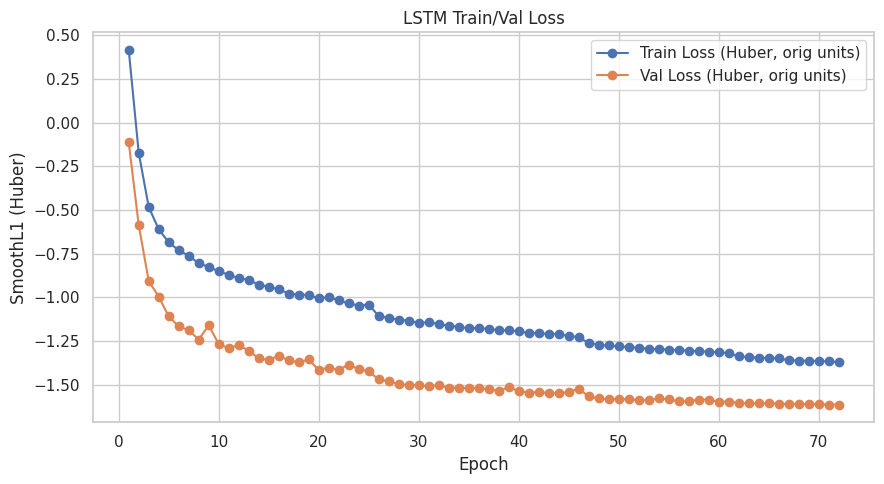

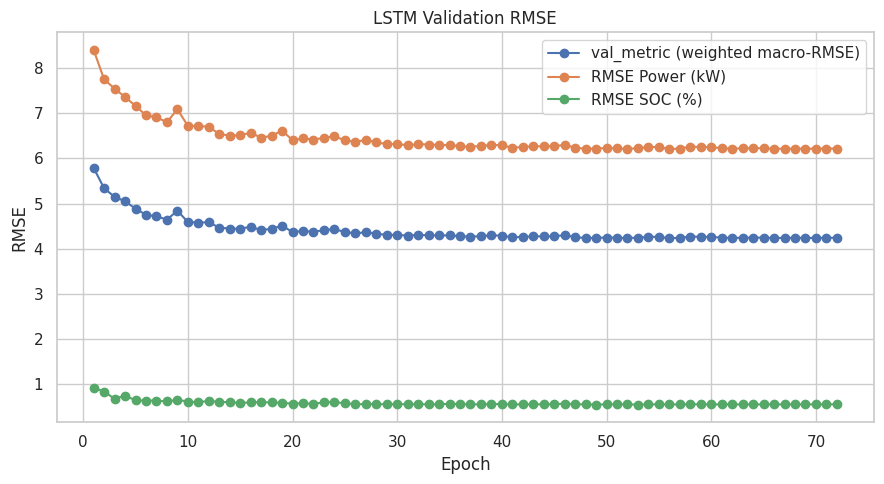

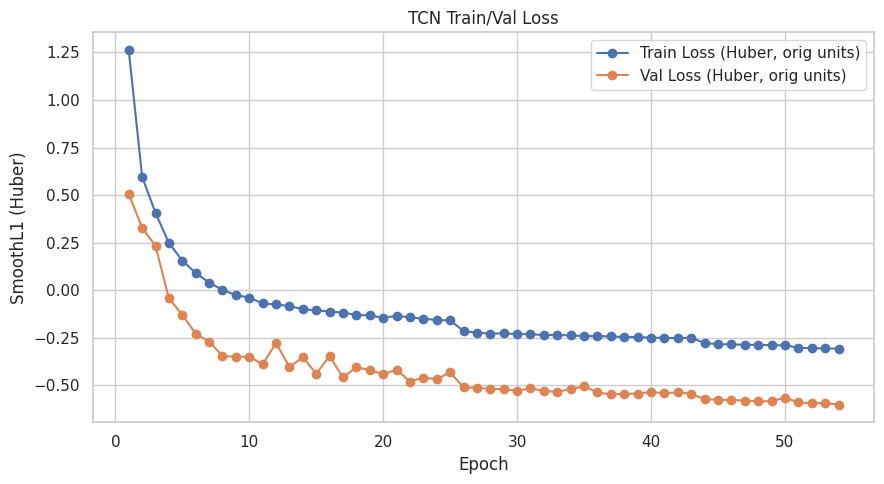

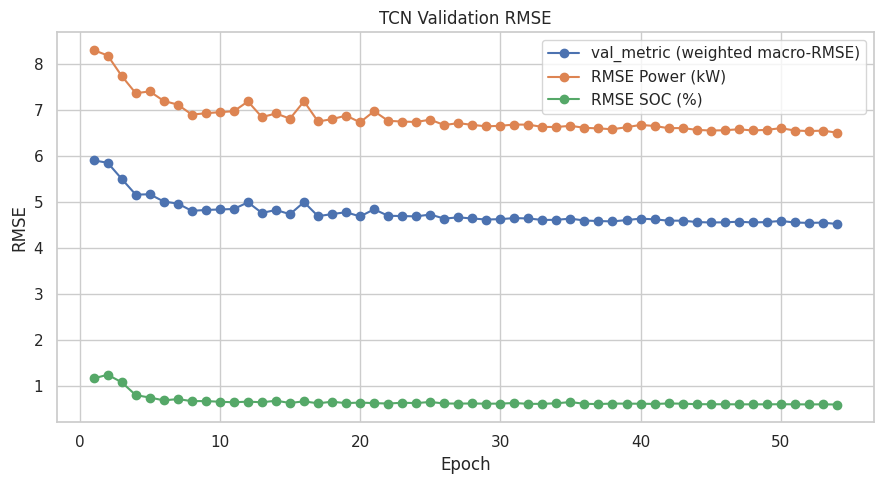

In [25]:
if best_lstm is not None: plot_best_curves(best_lstm, title_prefix="LSTM")
if best_tcn  is not None: plot_best_curves(best_tcn,  title_prefix="TCN")

 ## 5 - Model Evaluation and Selection



 **Macro-Averaging**: For each sequence, we compute the MSE across *its* valid time steps \((1 \le i < L - \text{horizon})\) and the entire horizon dimension. Then we average these sequence-level errors across all sequences.



 **Note**: During training we did a *micro-average* (standard approach). Below is an example of how to do the per-sequence macro-average on the test set.

### 5.1 Evaluating the models with macro averaging

In [26]:
def evaluate_model_macro_average(model: nn.Module,
                                 dataset: ChargingSessionDataset,
                                 batch_size: int,
                                 device: torch.device,
                                 power_scaler: MinMaxScaler,
                                 soc_scaler: MinMaxScaler):
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=session_collate_fn, shuffle=False)
    model.eval(); seq_mses = []
    with torch.no_grad():
        for X_batch, Y_batch, lengths in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            Y_batch = Y_batch.to(device, non_blocking=True)
            pred_resid, _ = model(X_batch, lengths)
            pred = reconstruct_abs_from_residuals_batch(pred_resid, X_batch, IDX_POWER, IDX_SOC)

            B, Tm, H, C = pred.shape
            for i in range(B):
                L = lengths[i].item()
                if L <= H + 1: continue
                s, e = 1, L - H

                pred_scaled = pred[i, :L]
                true_resid  = Y_batch[i, :L]
                xi = X_batch[i, :L, [IDX_POWER, IDX_SOC]].unsqueeze(1).expand(-1, H, -1)
                true_abs_scaled = true_resid + xi

                pv = pred_scaled[s:e]; tv = true_abs_scaled[s:e]

                p_power = power_scaler.inverse_transform(pv[..., 0].contiguous().view(-1,1).cpu().numpy()).ravel()
                p_soc   = soc_scaler.inverse_transform(  pv[..., 1].contiguous().view(-1,1).cpu().numpy()).ravel()
                t_power = power_scaler.inverse_transform(tv[..., 0].contiguous().view(-1,1).cpu().numpy()).ravel()
                t_soc   = soc_scaler.inverse_transform(  tv[..., 1].contiguous().view(-1,1).cpu().numpy()).ravel()

                seq_mses.append(mean_squared_error(
                    np.concatenate([t_power, t_soc]), np.concatenate([p_power, p_soc])
                ))
    return {"MacroMSE": float(np.mean(seq_mses)) if seq_mses else float("nan"),
            "NumSequencesEvaluated": len(seq_mses)}


# -- Evaluate whichever models are available --
if model_lstm is not None:
    stats_lstm = evaluate_model_macro_average(model_lstm, test_dataset, BATCH_SIZE, DEVICE, power_scaler, soc_scaler)
    print(f"[LSTM] Test Macro-Averaged MSE: {stats_lstm['MacroMSE']:.4f} "
          f"(across {stats_lstm['NumSequencesEvaluated']} sequences)")

if model_tcn is not None:
    stats_tcn = evaluate_model_macro_average(model_tcn, test_dataset, BATCH_SIZE, DEVICE, power_scaler, soc_scaler)
    print(f"[TCN]  Test Macro-Averaged MSE: {stats_tcn['MacroMSE']:.4f} "
          f"(across {stats_tcn['NumSequencesEvaluated']} sequences)")

[LSTM] Test Macro-Averaged MSE: 21.3304 (across 12340 sequences)
[TCN]  Test Macro-Averaged MSE: 23.0828 (across 12340 sequences)


 ### 5.2 Plotting Predictions

#### 5.2.1 Plotting Setup and Utility Functions

In [27]:
# -- Bundle helper to pull one batch & sample for plotting --
@dataclass
class SampleBundle:
    batch_index: int
    sample_index: int
    length: int
    horizon: int
    num_targets: int
    X_sample: torch.Tensor
    Y_sample: torch.Tensor
    P_sample: torch.Tensor
    true_power_unscaled: np.ndarray
    true_soc_unscaled:   np.ndarray

def _get_nth_batch(loader, n: int):
    it = iter(loader)
    for _ in range(n): next(it)
    return next(it)

@torch.no_grad()
def fetch_sample_bundle(model: nn.Module, loader: DataLoader,
                        batch_index: int, sample_index: int, device: torch.device,
                        power_scaler, soc_scaler) -> SampleBundle:
    model.eval()
    Xb, Yb, Ls = _get_nth_batch(loader, batch_index)
    if sample_index >= Xb.shape[0]:
        raise IndexError(f"sample_index {sample_index} out of range for batch {batch_index} (size={Xb.shape[0]}).")
    X_dev = Xb.to(device, non_blocking=True)
    P_dev, _ = model(X_dev, Ls)

    T = Ls[sample_index].item()
    P_s = P_dev[sample_index, :T].cpu()
    Y_s = Yb[sample_index, :T].cpu()
    X_s = Xb[sample_index, :T].cpu()

    H = P_s.shape[1]; C = P_s.shape[2]
    power_true = power_scaler.inverse_transform(X_s[:, [IDX_POWER]].numpy()).ravel()
    soc_true   = soc_scaler.inverse_transform(  X_s[:, [IDX_SOC  ]].numpy()).ravel()

    return SampleBundle(
        batch_index=batch_index, sample_index=sample_index,
        length=T, horizon=H, num_targets=C, X_sample=X_s, Y_sample=Y_s, P_sample=P_s,
        true_power_unscaled=power_true, true_soc_unscaled=soc_true,
    )

def _valid_time_bounds(T: int, H: int):
    return 1, max(1, T - H)  # [start, end_exclusive]

# -- Test loader for plotting (fixed order; no shuffle) --
test_sampler  = BucketBatchSampler(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_sampler=test_sampler, collate_fn=session_collate_fn,
                           num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)

# -- Example bundles (guarded by model availability) --
BATCH_INDEX, SAMPLE_INDEX = 30, 0
bundle_lstm = (fetch_sample_bundle(model_lstm, test_loader, BATCH_INDEX, SAMPLE_INDEX, DEVICE, power_scaler, soc_scaler)
               if model_lstm is not None else None)
bundle_tcn  = (fetch_sample_bundle(model_tcn,  test_loader, BATCH_INDEX, SAMPLE_INDEX, DEVICE, power_scaler, soc_scaler)
               if model_tcn  is not None else None)

# -- Reconstruct absolute predictions from a bundle (scaled space) --
def reconstruct_abs_from_bundle(bundle: SampleBundle, idx_power: int, idx_soc: int):
    base = bundle.X_sample[:, [idx_power, idx_soc]].unsqueeze(1)
    return bundle.P_sample + base

# -- Plot inputs (orig units) vs single future point (pred/true) --
def plot_inputs_to_single_output_grid(bundle: SampleBundle, i_list: List[int], horizon: int=1,
                                      target: str="power", features_to_show: Optional[List[str]]=None,
                                      power_scaler=None, soc_scaler=None, window_len: Optional[int]=30,
                                      ncols: int=3, right_pad_steps: float=1.8, annotate: bool=True,
                                      enforce_same_units: bool=True):
    assert target in {"power","soc"}
    H, T = bundle.horizon, bundle.length
    h = max(1, min(horizon, H))
    start_valid, end_valid_excl = _valid_time_bounds(T, H)

    clamped = []
    for i0 in i_list:
        j = min(max(i0, start_valid), end_valid_excl - 1)
        if start_valid <= j < end_valid_excl: clamped.append(j)
    if not clamped: raise ValueError(f"No valid i0; valid range is 1..{T-H-1}.")

    power_unscaled = bundle.true_power_unscaled
    soc_unscaled   = bundle.true_soc_unscaled

    feats_map = {"power": power_unscaled, "soc": soc_unscaled}
    if features_to_show is None:
        features_to_show = ["power"] if target == "power" else ["soc"]
    if enforce_same_units:
        allowed = {"power"} if target == "power" else {"soc"}
        features_to_show = [f for f in features_to_show if f in allowed]
        if not features_to_show: features_to_show = list(allowed)
    else:
        features_to_show = [f for f in features_to_show if f in feats_map]

    t_scaler = power_scaler if target == "power" else soc_scaler
    target_idx = 0 if target == "power" else 1
    y_label = "Power (kW)" if target == "power" else "SOC (%)"

    n = len(clamped); ncols = max(1, ncols); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2*ncols, 4.2*nrows), squeeze=False)
    palette = sns.color_palette("deep", n_colors=len(features_to_show))

    P_abs = reconstruct_abs_from_bundle(bundle, IDX_POWER, IDX_SOC)

    for ax, i0 in zip(axes.ravel(), clamped):
        if window_len is None: w0, w1 = 0, i0 + 1
        else: w0, w1 = max(0, i0 - window_len + 1), i0 + 1
        tt = np.arange(w0, w1)

        ymins, ymaxs = [], []
        for ci, f in enumerate(features_to_show):
            series = feats_map[f][w0:w1]
            ax.plot(tt, series, label=f, linewidth=2, color=palette[ci])
            ymins.append(series.min()); ymaxs.append(series.max())

        t_pred = i0 + h
        y_pred = P_abs[i0, h-1, target_idx].numpy().reshape(1,1)
        base_i = bundle.X_sample[i0, [IDX_POWER, IDX_SOC]][target_idx].item()
        y_true = np.array([[bundle.Y_sample[i0, h-1, target_idx].item() + base_i]], dtype=np.float32)

        y_pred = t_scaler.inverse_transform(y_pred).ravel()[0]
        y_true = t_scaler.inverse_transform(y_true).ravel()[0]

        ax.scatter([t_pred], [y_pred], s=120, marker="x", linewidths=2.5, color="tab:red",  zorder=5, label="Pred")
        ax.scatter([t_pred], [y_true], s=120, marker="x", linewidths=2.5, color="tab:blue", zorder=5, label="True")

        if annotate:
            ax.annotate(f"{y_pred:.2f}", (t_pred, y_pred), textcoords="offset points", xytext=(6, 8),  fontsize=8, color="tab:red")
            ax.annotate(f"{y_true:.2f}", (t_pred, y_true), textcoords="offset points", xytext=(6,-14), fontsize=8, color="tab:blue")

        ymins.append(min(y_pred, y_true)); ymaxs.append(max(y_pred, y_true))
        y_lo, y_hi = min(ymins), max(ymaxs); span = max(1e-9, y_hi - y_lo); pad = 0.08 * span if span > 0 else 0.5
        ax.set_ylim(y_lo - pad, y_hi + pad)

        ax.axvline(i0, color="black", linestyle=":", linewidth=1.8)
        ax.set_xlim(min(w0, t_pred), max(w1 - 1, t_pred) + right_pad_steps)

        ax.set_title(f"i0={i0}, H={h} → t={t_pred} | batch {bundle.batch_index}, sample {bundle.sample_index}")
        ax.set_xlabel("Time index"); ax.set_ylabel(y_label)
        ax.grid(True); ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)); ax.legend(fontsize=8, loc="upper left")

    for k in range(len(clamped), nrows*ncols):
        axes.ravel()[k].set_axis_off()
    fig.suptitle(f"Inputs → Single {target.upper()} output @ H={h}", y=1.02, fontsize=12)
    plt.tight_layout(); plt.show()

#### 5.2.2 Plotting input-output pairs at time t for a single session

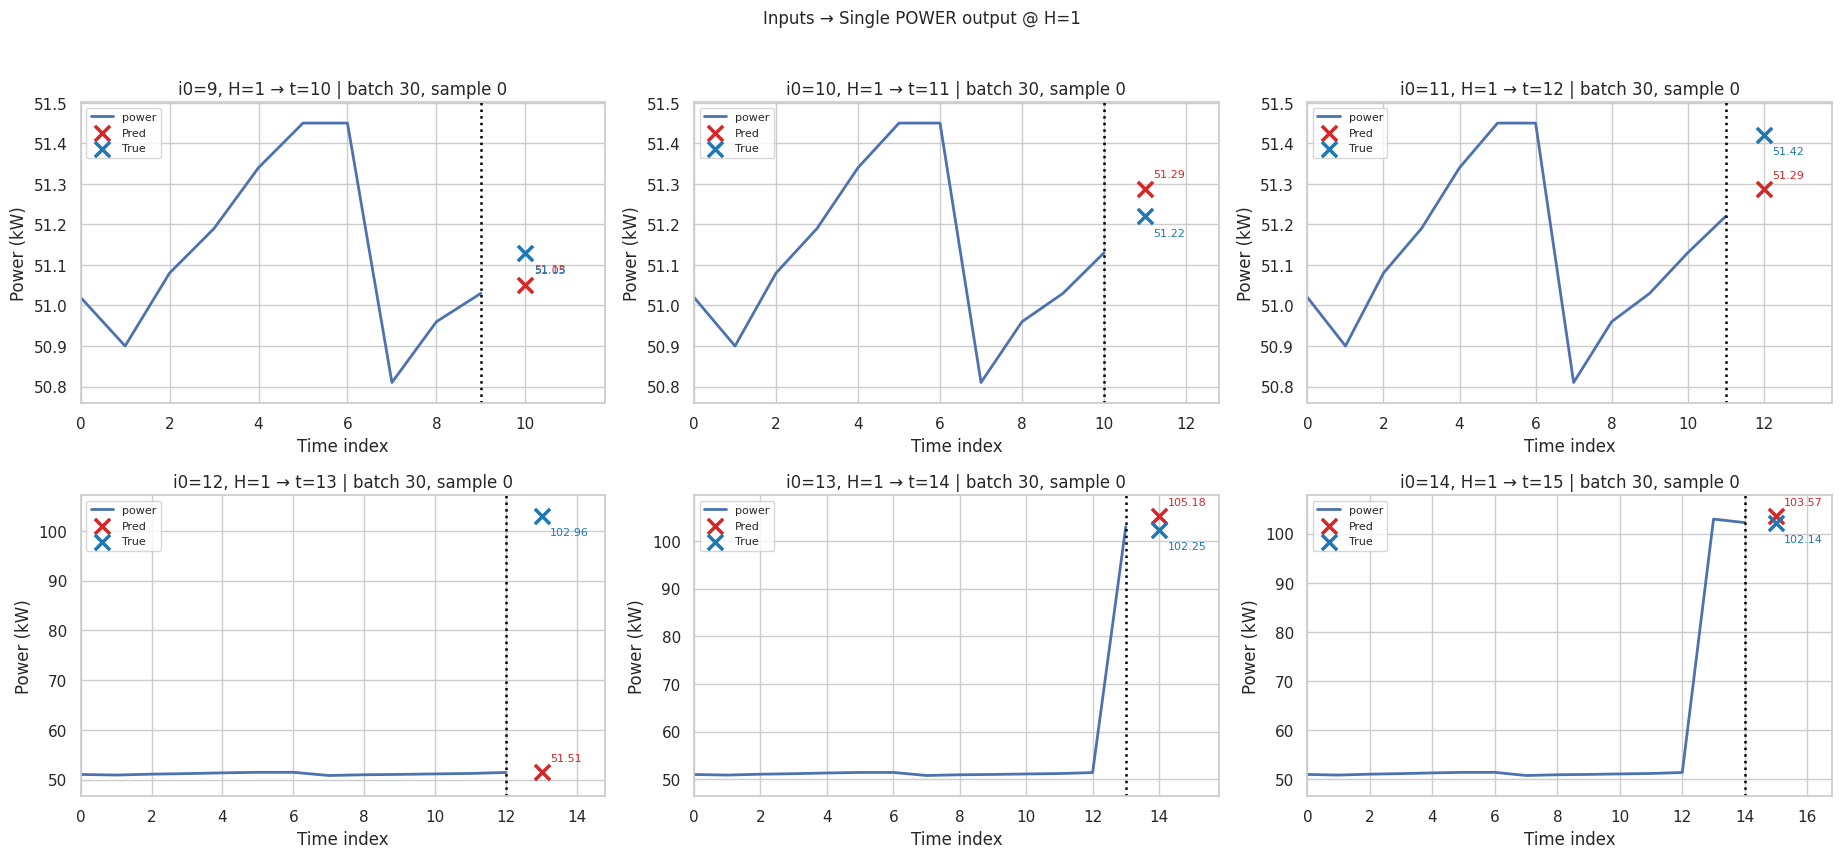

In [31]:
if bundle_lstm is not None:
    plot_inputs_to_single_output_grid(bundle_lstm, i_list=[9,10,11,12,13,14], horizon=1, target="power",
                                      features_to_show=["power"], power_scaler=power_scaler, soc_scaler=soc_scaler,
                                      window_len=30, ncols=3, enforce_same_units=True)

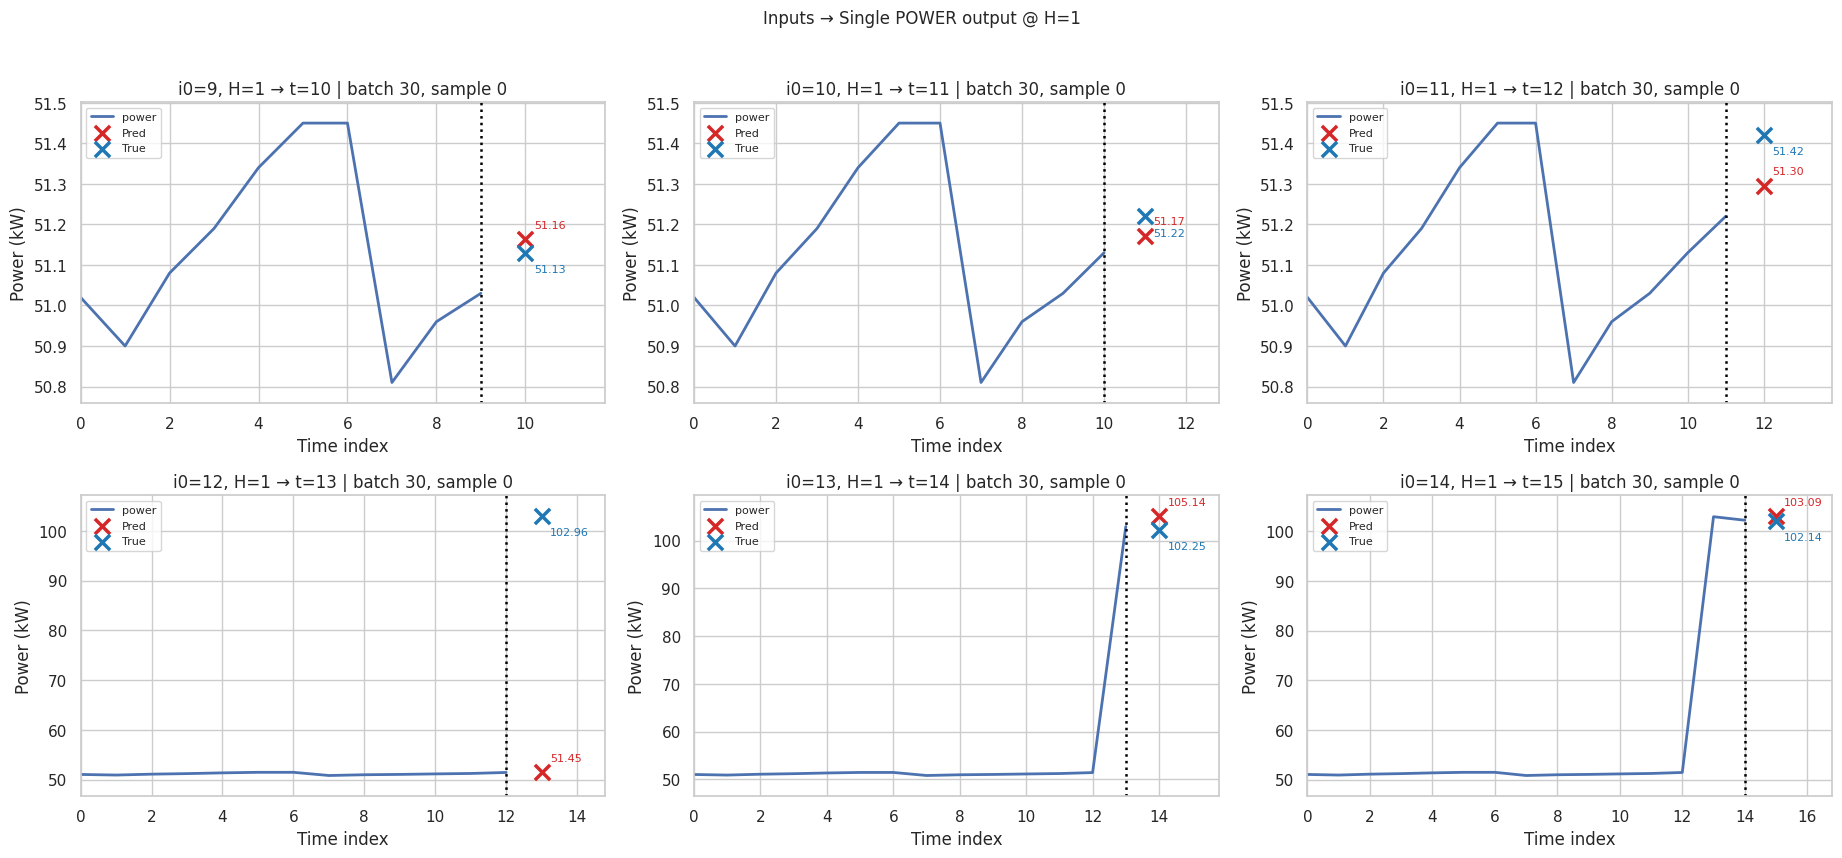

In [32]:
if bundle_tcn is not None:
    plot_inputs_to_single_output_grid(bundle_tcn, i_list=[9,10,11,12,13,14], horizon=1, target="power",
                                      features_to_show=["power"], power_scaler=power_scaler, soc_scaler=soc_scaler,
                                      window_len=30, ncols=3, enforce_same_units=True)

#### 5.2.3 Plotting Multi-Horizon Predictions for a Full Session

In [28]:
def plot_full_session(bundle: SampleBundle, power_scaler, soc_scaler, target="power", title_suffix=""):
    assert target in {"power","soc"}
    T, H = bundle.length, bundle.horizon
    t = np.arange(T); idx = 0 if target=="power" else 1
    scaler = power_scaler if target=="power" else soc_scaler
    true = bundle.true_power_unscaled if idx==0 else bundle.true_soc_unscaled

    plt.figure(figsize=(10,5))
    sns.lineplot(x=t, y=true, color="black", linewidth=2.5, label=f"True {target.title()}")

    palette = sns.color_palette("deep", n_colors=H)
    P_abs = reconstruct_abs_from_bundle(bundle, IDX_POWER, IDX_SOC)
    for h0 in range(H):
        i_valid = np.arange(1, T - (h0+1))
        t_abs = i_valid + (h0+1)
        preds = scaler.inverse_transform(P_abs[i_valid, h0, idx].numpy().reshape(-1,1)).ravel()
        sns.lineplot(x=t_abs, y=preds, linestyle="--", linewidth=1.8, color=palette[h0],
                     label=f"Horizon={h0+1}", marker="o", markersize=3)
        plt.scatter(t_abs, preds, s=10, color=palette[h0], alpha=0.5)

    plt.title(f"{target.upper()} predictions — batch {bundle.batch_index}, sample {bundle.sample_index}{title_suffix}")
    plt.xlabel("Time index"); plt.ylabel("Power (kW)" if idx==0 else "SOC (%)")
    plt.grid(True); plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.legend(); plt.tight_layout(); plt.show()
    plt.tight_layout(); plt.show()

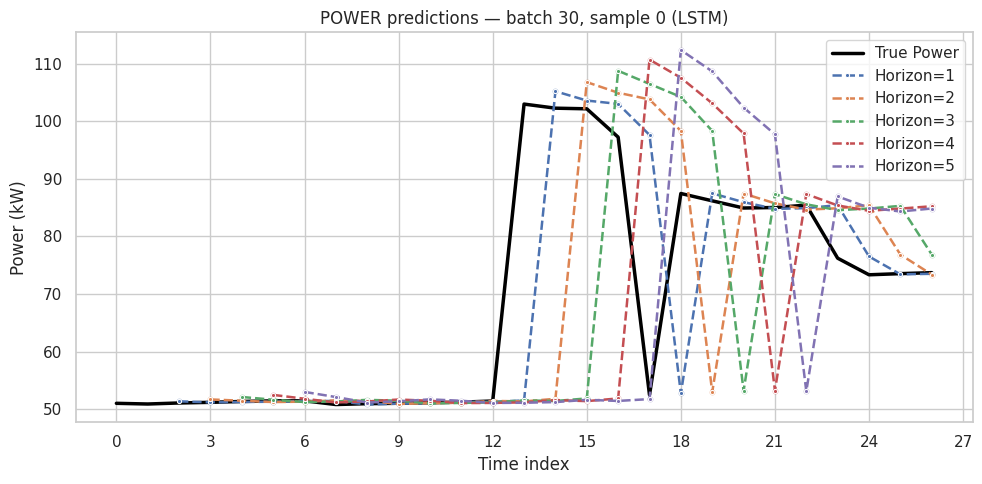

<Figure size 640x480 with 0 Axes>

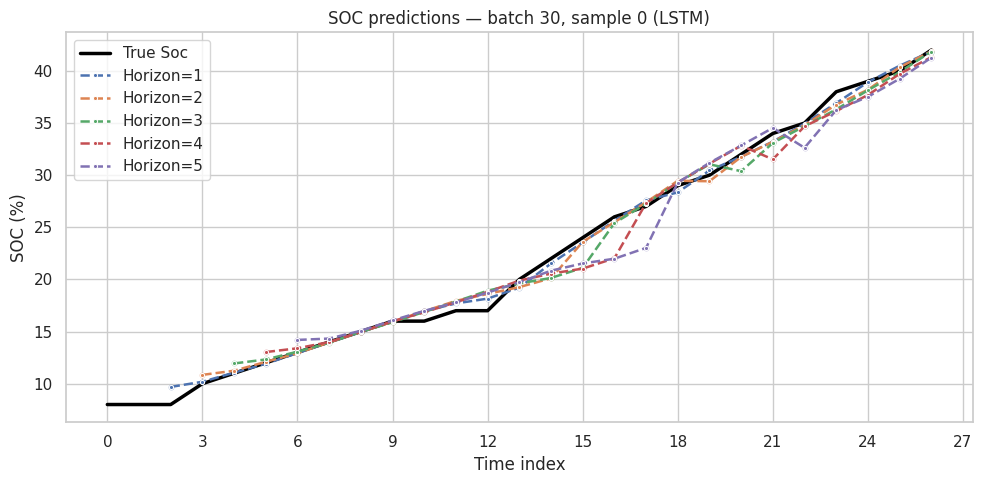

<Figure size 640x480 with 0 Axes>

In [29]:
if bundle_lstm is not None:
    plot_full_session(bundle_lstm, power_scaler, soc_scaler, target="power", title_suffix=" (LSTM)")
    plot_full_session(bundle_lstm, power_scaler, soc_scaler, target="soc",   title_suffix=" (LSTM)")

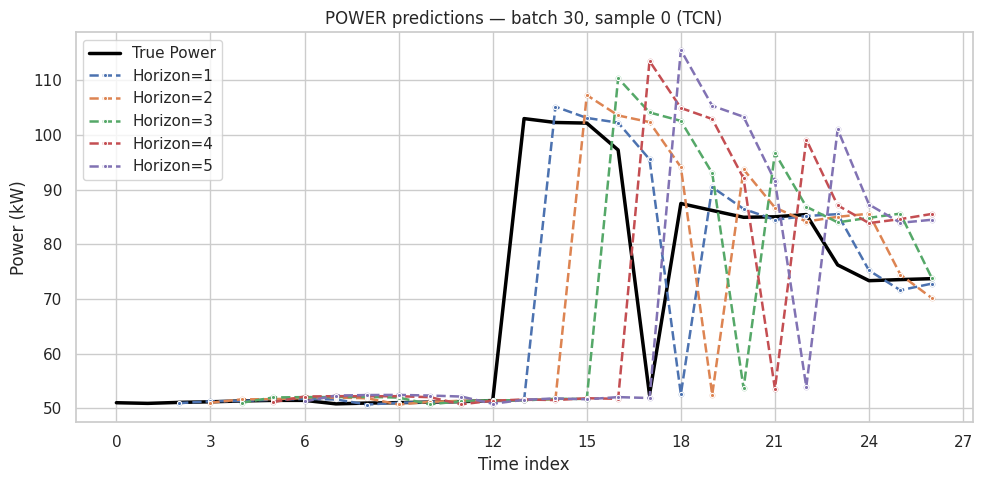

<Figure size 640x480 with 0 Axes>

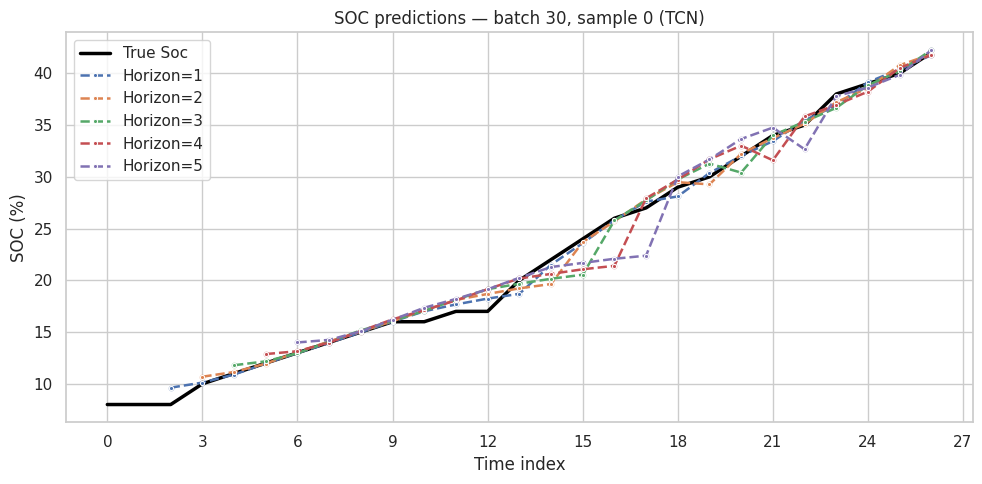

<Figure size 640x480 with 0 Axes>

In [30]:
if bundle_tcn is not None:
    plot_full_session(bundle_tcn, power_scaler, soc_scaler, target="power", title_suffix=" (TCN)")
    plot_full_session(bundle_tcn, power_scaler, soc_scaler, target="soc",   title_suffix=" (TCN)")

#### 5.2.4 Plotting Complete Power Predictions for Multiple Sample Sessions

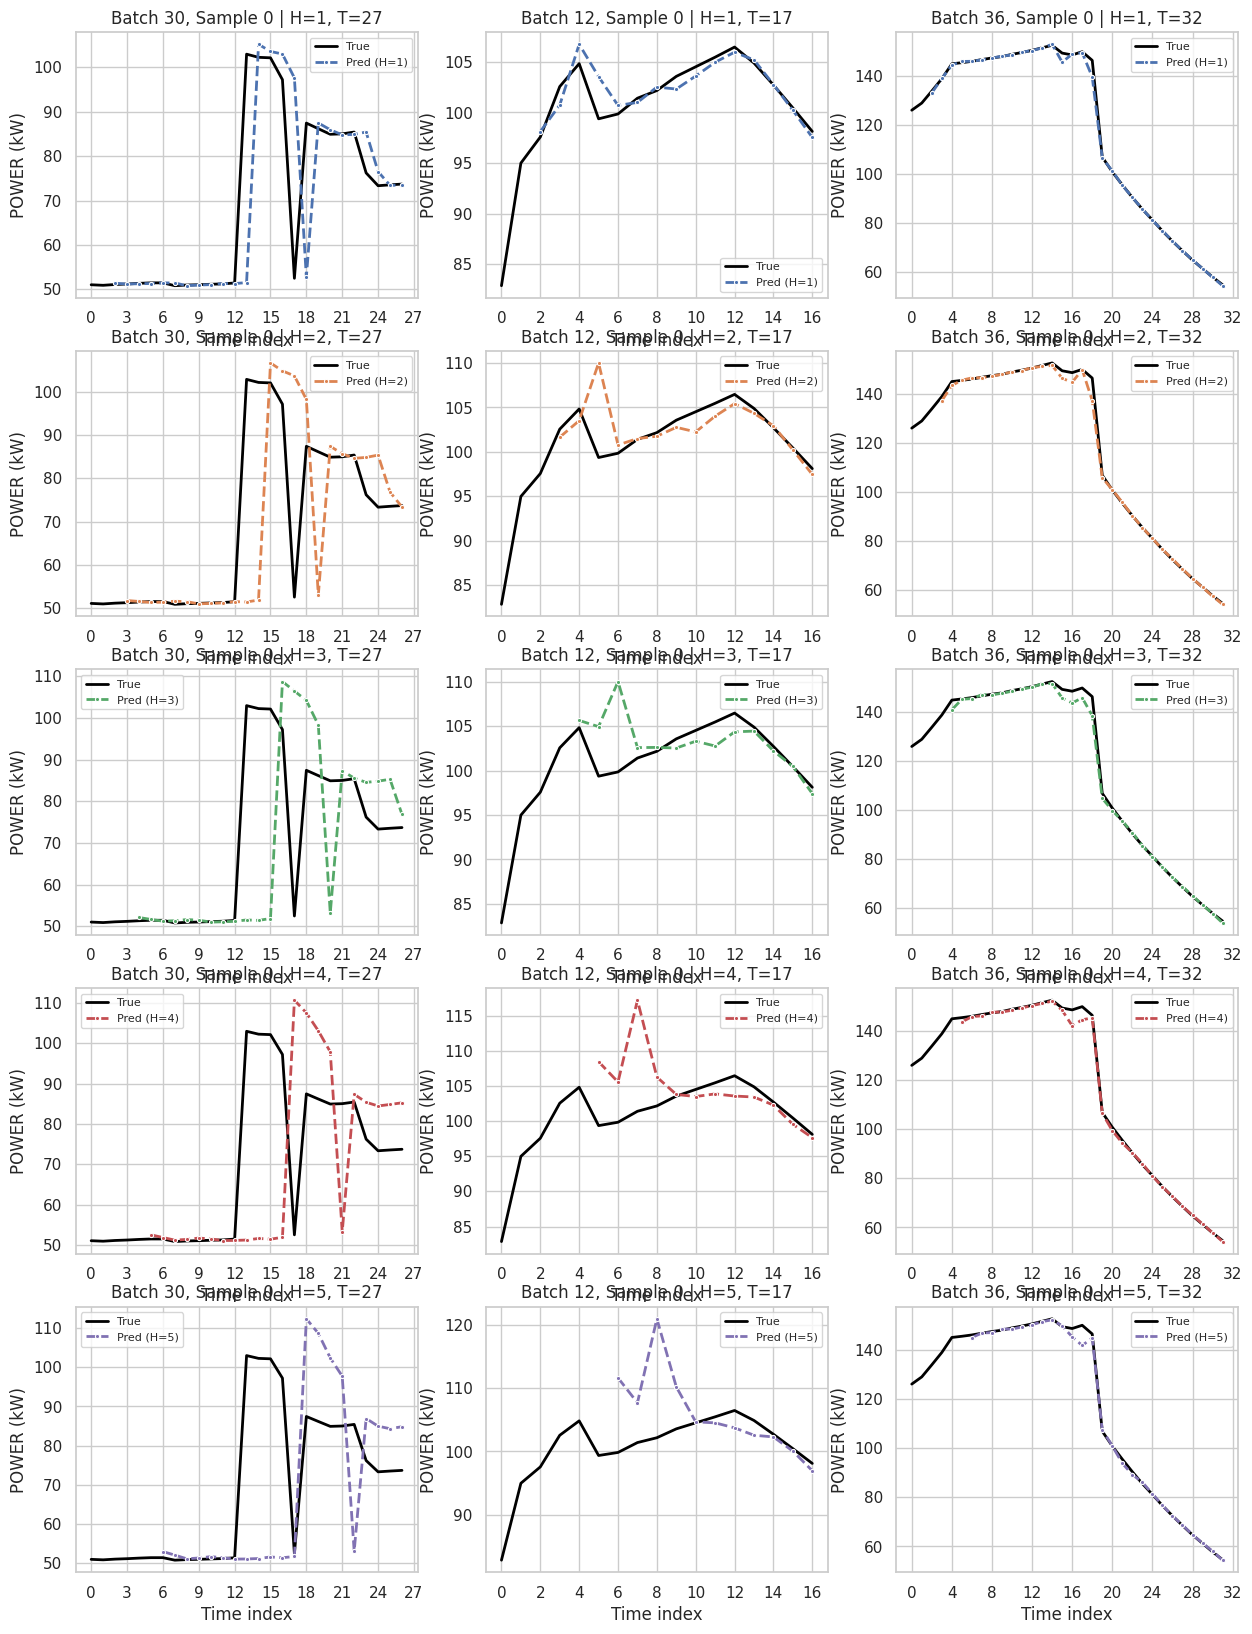

In [34]:
def plot_grid_by_horizon(bundles: List[SampleBundle], power_scaler, soc_scaler, target: str="power"):
    assert target in {"power","soc"}
    H = bundles[0].horizon; target_idx = 0 if target=="power" else 1
    scaler = power_scaler if target=="power" else soc_scaler
    ncols = len(bundles)
    fig, axes = plt.subplots(nrows=H, ncols=ncols, figsize=(5*ncols, 4*H), squeeze=False, sharex=False, sharey=False)
    palette = sns.color_palette("deep", n_colors=H)

    for col, b in enumerate(bundles):
        T = b.length; t_true = np.arange(T)
        true_unscaled = b.true_power_unscaled if target_idx==0 else b.true_soc_unscaled
        for h0 in range(H):
            ax = axes[h0, col]; h1 = h0 + 1
            i_valid = np.arange(1, T - h1)
            if i_valid.size == 0:
                ax.text(0.5, 0.5, "No valid preds", ha="center", va="center"); ax.set_axis_off(); continue
            t_pred = i_valid + h1
            P_abs = reconstruct_abs_from_bundle(b, IDX_POWER, IDX_SOC)
            preds = scaler.inverse_transform(P_abs[i_valid, h0, target_idx].numpy().reshape(-1,1)).ravel()

            sns.lineplot(x=t_true, y=true_unscaled, color="black", linewidth=2, label="True", ax=ax)
            sns.lineplot(x=t_pred, y=preds, linestyle="--", linewidth=2, color=palette[h0],
                         label=f"Pred (H={h1})", marker="o", markersize=3, ax=ax)

            ax.set_title(f"Batch {b.batch_index}, Sample {b.sample_index} | H={h1}, T={T}")
            ax.set_xlabel("Time index"); ax.set_ylabel("POWER (kW)" if target_idx==0 else "SOC (%)")
            ax.grid(True); ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)); ax.legend(fontsize=8)


if model_lstm is not None:
    bundles_l = [
        fetch_sample_bundle(model_lstm, test_loader, BATCH_INDEX, SAMPLE_INDEX, DEVICE, power_scaler, soc_scaler),
        fetch_sample_bundle(model_lstm, test_loader, 12, 0, DEVICE, power_scaler, soc_scaler),
        fetch_sample_bundle(model_lstm, test_loader, 36, 0, DEVICE, power_scaler, soc_scaler),
    ]
    plot_grid_by_horizon(bundles_l, power_scaler, soc_scaler, target="power")

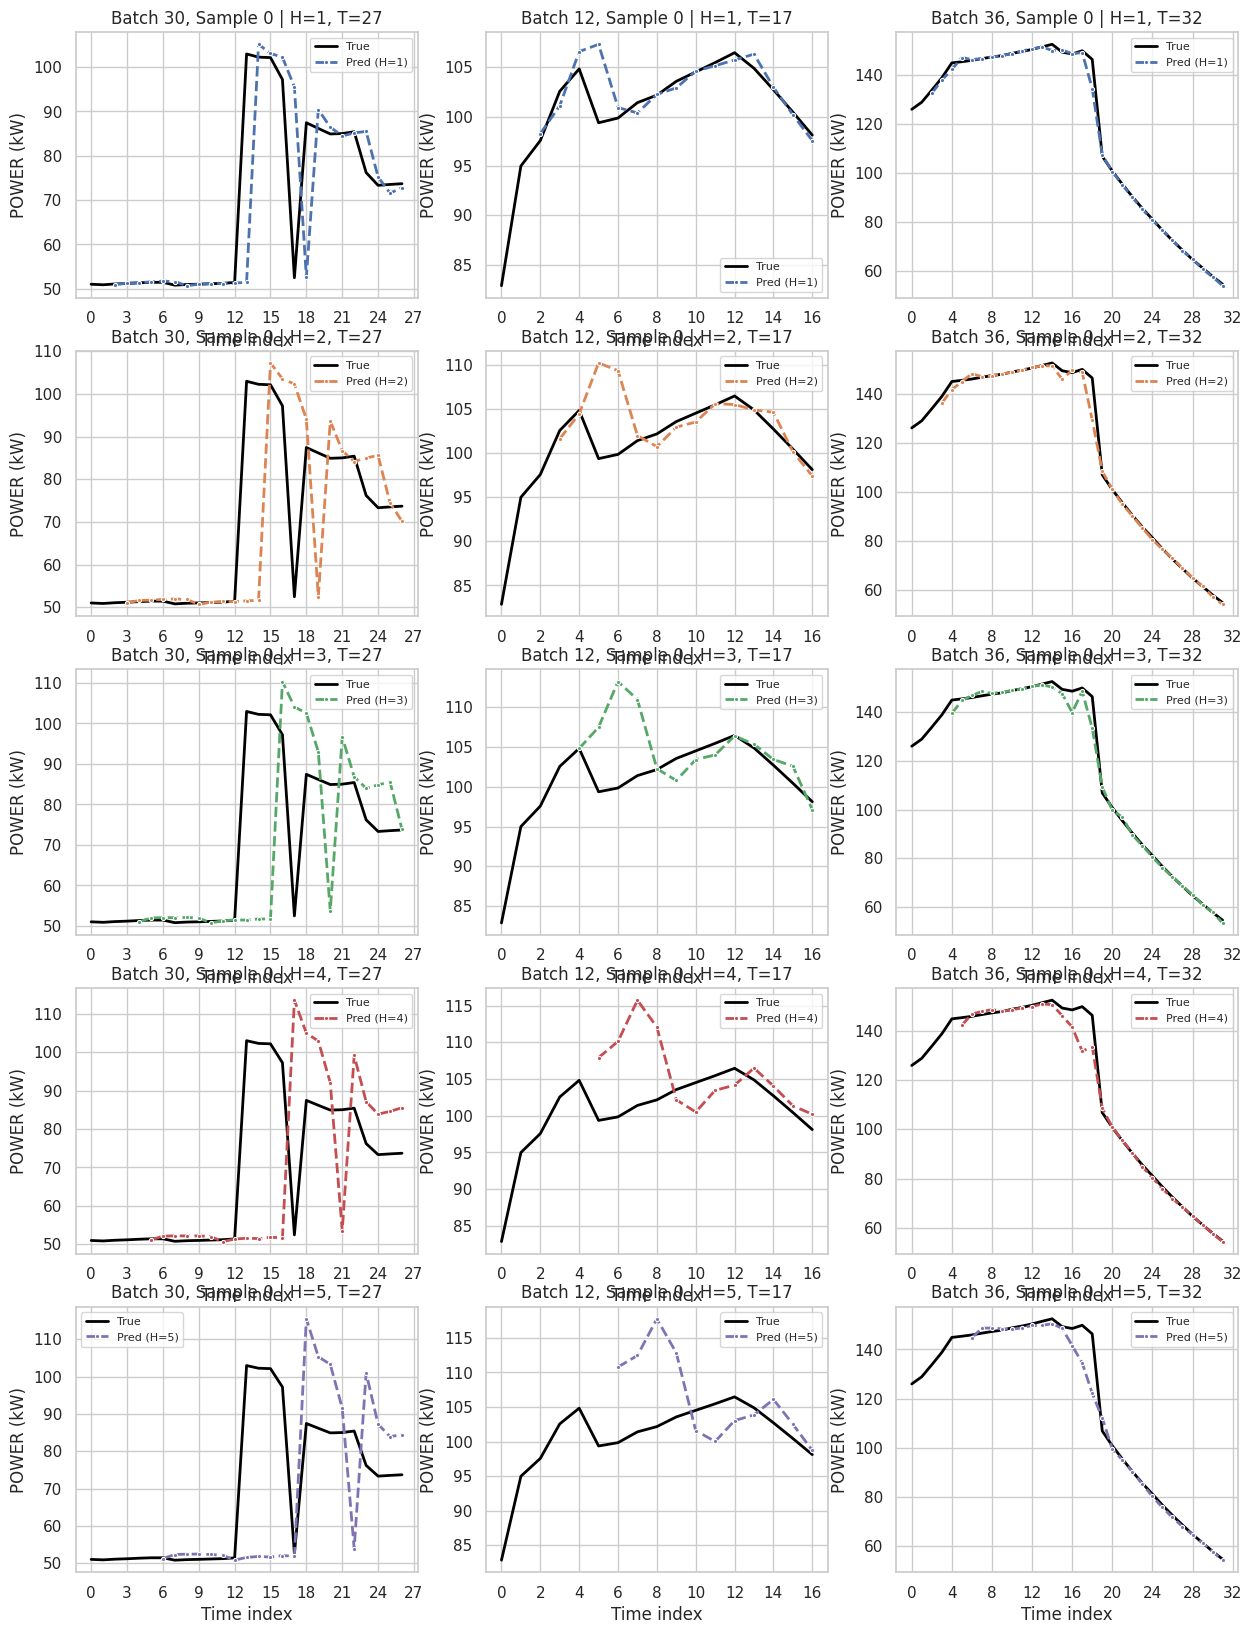

In [35]:
if model_tcn is not None:
    bundles_c = [
        fetch_sample_bundle(model_tcn, test_loader, BATCH_INDEX, SAMPLE_INDEX, DEVICE, power_scaler, soc_scaler),
        fetch_sample_bundle(model_tcn, test_loader, 12, 0, DEVICE, power_scaler, soc_scaler),
        fetch_sample_bundle(model_tcn, test_loader, 36, 0, DEVICE, power_scaler, soc_scaler),
    ]
    plot_grid_by_horizon(bundles_c, power_scaler, soc_scaler, target="power")

#### 5.3 Model Selection

#### 5.4 Summary and Next Steps